<a href="https://colab.research.google.com/github/hephz-pekun/AI201-Takemeter/blob/main/AI201_project3_takemeter_starter_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [56]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [57]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [58]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "Recommendation":  0,   # ← Replace with your first label
    "Review":  1,   # ← Replace with your second label
    "Literary_Analysis":  2,   # ← Replace with your third label (remove if you have 2 labels)
    "Publishing_and_Book_Info": 3,   # ← Uncommented since I have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'Recommendation': 0, 'Review': 1, 'Literary_Analysis': 2, 'Publishing_and_Book_Info': 3}
Number of labels: 4


In [59]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving Books Dataset - Sheet1.csv to Books Dataset - Sheet1 (3).csv
Uploaded: Books Dataset - Sheet1 (3).csv


In [60]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

# Rename columns from CSV to notebook format
df = df.rename(columns={
    "Text": "text",
    "Label": "label"
})

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()

print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️ Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['label', 'text']
Total examples: 199

Label distribution:
label
Review                      50
Literary_Analysis           50
Publishing_and_Book_Info    50
Recommendation              49
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [61]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 139 examples
Validation: 30 examples
Test: 30 examples

Train label distribution:
label
Literary_Analysis           35
Review                      35
Publishing_and_Book_Info    35
Recommendation              34
Name: count, dtype: int64

Test label distribution:
label
Recommendation              8
Literary_Analysis           8
Publishing_and_Book_Info    7
Review                      7
Name: count, dtype: int64


In [62]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/139 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [63]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [64]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [65]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.389819,0.200000
2,1.389114,1.377225,0.300000
3,1.380001,1.352467,0.600000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [66]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.700

Per-class metrics (fine-tuned model):
                          precision    recall  f1-score   support

          Recommendation       0.67      0.75      0.71         8
                  Review       1.00      0.57      0.73         7
       Literary_Analysis       0.62      0.62      0.62         8
Publishing_and_Book_Info       0.67      0.86      0.75         7

                accuracy                           0.70        30
               macro avg       0.74      0.70      0.70        30
            weighted avg       0.73      0.70      0.70        30



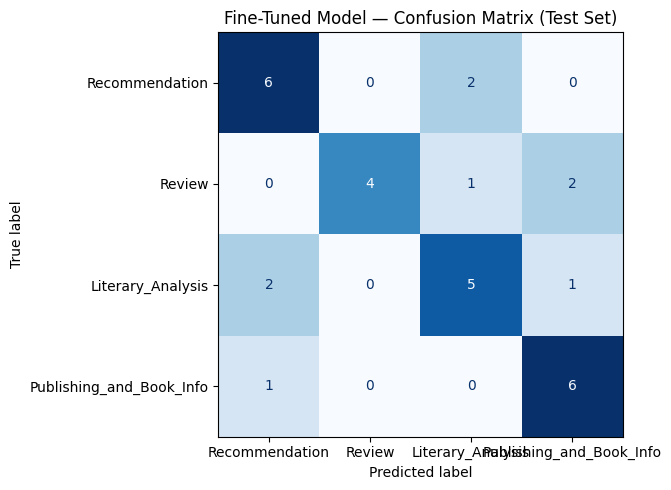

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [67]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [69]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 9 / 30

--- #1 ---
Text:      I recommend Iron Widow to readers who enjoy science fiction and strong character-driven stories. The novel explores patriarchy while delivering an exciting plot.
True:      Recommendation
Predicted: Literary_Analysis  (confidence: 0.26)

--- #2 ---
Text:      The burden on Christian's back...ooohhhh so easy...In all seriousness - the turtle I suppose from Grapes of Wrath. Or the conch from LOtF. Or the gate to the law in The Trial. Or Quentin's shadow in T...
True:      Literary_Analysis
Predicted: Recommendation  (confidence: 0.27)

--- #3 ---
Text:      Ahh, I’ve got the perfect book! It’s called We Need to Talk About Kevin. Such a fun and uplifting book about a mom and her son!
True:      Recommendation
Predicted: Literary_Analysis  (confidence: 0.26)

--- #4 ---
Text:      Harry Potter and da Vinci code were both all night readathons for me, can’t say I love Jk’s politics these days but 14 year old me was enchanted
True:      Review


---
### Sample classifications for your README

Your evaluation report needs a **Sample Classifications** table: 3–5 posts with the predicted label
and its confidence, **including at least one correctly-predicted example** you explain.

The cell above only lists *wrong* predictions, so run this one to get a mix. It prints a ready-to-paste
markdown table — write it into your README as text, not a screenshot.

In [70]:
# Sample classifications table for your README (3-5 rows, correct + incorrect).
# Adjust the two counts if you want a different mix.

N_CORRECT, N_WRONG = 3, 2

correct_positions = np.where(ft_pred_ids == ft_true_ids)[0]
wrong_positions   = np.where(ft_pred_ids != ft_true_ids)[0]

if len(correct_positions) == 0:
    print("No correct predictions on the test set - check your label map and training run.")

sample = list(correct_positions[:N_CORRECT]) + list(wrong_positions[:N_WRONG])

print("| Post (truncated) | True label | Predicted | Confidence | Correct? |")
print("|---|---|---|---|---|")
for idx in sample:
    text = str(test_df.iloc[idx]["text"]).replace("|", "\\|").replace("\n", " ")
    if len(text) > 90:
        text = text[:90] + "..."
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    mark = "yes" if pred_label == true_label else "no"
    print(f"| {text} | {true_label} | {pred_label} | {confidence:.2f} | {mark} |")

print()
print("Paste this table into your README under 'Sample Classifications'.")
print("For at least one correct row, add a sentence on why that prediction is reasonable.")

| Post (truncated) | True label | Predicted | Confidence | Correct? |
|---|---|---|---|---|
| I would recommend The Charioteer by Mary Renault, especially to readers interested in char... | Recommendation | Recommendation | 0.28 | yes |
| If you enjoy science fiction, I recommend Blindsight by Peter Watts and the Bobiverse seri... | Recommendation | Recommendation | 0.27 | yes |
| My recommendation would be Survivor by Chuck Palahniuk. I often suggest it to readers who ... | Recommendation | Recommendation | 0.27 | yes |
| I recommend Iron Widow to readers who enjoy science fiction and strong character-driven st... | Recommendation | Literary_Analysis | 0.26 | no |
| The burden on Christian's back...ooohhhh so easy...In all seriousness - the turtle I suppo... | Literary_Analysis | Recommendation | 0.27 | no |

Paste this table into your README under 'Sample Classifications'.
For at least one correct row, add a sentence on why that prediction is reasonable.


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `openai/gpt-oss-20b`.  
You need to write the classification prompt using your label definitions.

In [71]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [72]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying posts from r/books.

Assign each post to exactly one label.

Recommendation:
Suggesting, requesting, recommending, or promoting a book to read.

Review:
Evaluating a book based on personal reading experience, discussing enjoyment, quality, strengths, or weaknesses.

Literary_Analysis:
Discussing symbolism, themes, interpretation, literary devices, author intent, or deeper meaning.

Publishing_and_Book_Info:
Sharing factual information about books, authors, publishing history, new releases, adaptations, awards, or literary trivia.

Return ONLY ONE of the following labels:

Recommendation
Review
Literary_Analysis
Publishing_and_Book_Info

Do not explain your answer.
Return only the label.
"""
print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 717 characters


In [73]:
def classify_with_groq(text):
    try:
        response = client.chat.completions.create(
            model="openai/gpt-oss-20b",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=100,
        )
        raw = response.choices[0].message.content.strip()

        raw_lower = raw.lower()

        for label in sorted(LABEL_MAP.keys(), key=len, reverse=True):
          if label.lower() in raw_lower:
            return label
        return None

    except Exception as e:
        print(f"API error: {e}")
        return None


In [74]:
# Baseline metrics (exclude unparseable responses)
# Run baseline predictions
baseline_preds = []

for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])

    baseline_preds.append(pred)

# Check first few predictions
print("\nFirst 10 predictions:")
print(baseline_preds[:10])

# Baseline metrics (exclude unparseable responses)
valid = [
    (p, t)
    for p, t in zip(baseline_preds, test_df["label_id"])
    if p is not None
]

print("Valid predictions:", len(valid))

bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

if len(valid) == 0:
    print("No parseable baseline predictions.")
else:
    bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)

    print(
        f"🎯 Baseline accuracy: {bl_accuracy:.3f} "
        f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)"
    )

    label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]

    print("\nPer-class metrics (baseline):")
    print(
        classification_report(
            bl_true_ids,
            bl_pred_ids,
            target_names=label_names,
            zero_division=0,
        )
    )


First 10 predictions:
['Recommendation', 'Recommendation', 'Recommendation', 'Recommendation', None, 'Publishing_and_Book_Info', None, None, 'Publishing_and_Book_Info', 'Recommendation']
Valid predictions: 22
🎯 Baseline accuracy: 0.909 (evaluated on 22/30 parseable responses)

Per-class metrics (baseline):
                          precision    recall  f1-score   support

          Recommendation       0.89      1.00      0.94         8
                  Review       0.67      1.00      0.80         2
       Literary_Analysis       1.00      1.00      1.00         5
Publishing_and_Book_Info       1.00      0.71      0.83         7

                accuracy                           0.91        22
               macro avg       0.89      0.93      0.89        22
            weighted avg       0.93      0.91      0.91        22



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [75]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.909
Fine-tuned DistilBERT                  0.700
---------------------------------------------

Fine-tuning regression: 0.209

Use these numbers in your README evaluation report.


In [76]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
